In [1]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Literal
from typing_extensions import Annotated
# reducer
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
import os
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()
project = os.getenv('GOOGLE_CLOUD_PROJECT')


# model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai = True,
    project = project
)

In [2]:
from langgraph.graph import MessagesState

In [3]:
def node_1(state: MessagesState):
    role = [SystemMessage(content="You are expert in the field of Software")]
    
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

def node_2(state: MessagesState):
    role = [SystemMessage(content="You are helpful assistant")]
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

In [4]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)

In [5]:
# sequence 

graph.set_entry_point("expert")
graph.add_edge("expert", "assistant")
graph.set_finish_point("assistant")

In [6]:
state_graph = graph.compile()

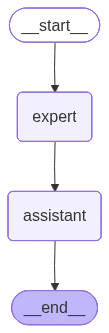

In [7]:
state_graph

In [10]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'consumer': 'projects/munna-genai', 'service': 'aiplatform.googleapis.com', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'containerInfo': 'munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [11]:
for message in response['messages']:
    print(message.content)

NameError: name 'response' is not defined

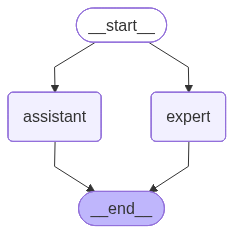

In [12]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)
graph.set_entry_point("expert")
graph.set_entry_point("assistant")
graph.set_finish_point("assistant")
graph.set_finish_point("expert")
state_graph = graph.compile()
state_graph

In [13]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

for message in response['messages']:
    print(message.content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [14]:
# Sample Structure used 

class ExtendedMessagesState(MessagesState):
    expert_one: str = "Software"
    expert_two: str = "Design"

In [15]:
# Simulate chat bot

def ask_question(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}
chat_graph = StateGraph(MessagesState)
chat_graph.add_node("chat", ask_question)
chat_graph.set_entry_point("chat")
chat_graph.set_finish_point("chat")
chat_state_graph = chat_graph.compile()

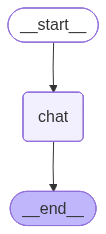

In [16]:
chat_state_graph

In [17]:
# in my state i have list of lenght 1
response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
})

len(response['messages'])

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [18]:
response['messages'][-1].pretty_print()

NameError: name 'response' is not defined

In [19]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What are good spots in the city")]}
)
response['messages'][-1].pretty_print()

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [20]:
config = {"configurable": {"thread_id": "3"}}

response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
}, config=config
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'consumer': 'projects/munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'containerInfo': 'munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [21]:
len(response['messages'])

NameError: name 'response' is not defined

In [22]:
response['messages'][-1].pretty_print()

NameError: name 'response' is not defined

In [23]:
response = chat_state_graph.invoke(
    {
        "messages": [HumanMessage(content="What are good spots in this city")]
    },
    config=config
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [24]:
len(response['messages'])

NameError: name 'response' is not defined

In [25]:
response['messages']

NameError: name 'response' is not defined

In [26]:
response['messages'][-1].pretty_print()

NameError: name 'response' is not defined

In [27]:
def response_from_llm(state: MessagesState):
    return {
        "messages": llm.invoke(state["messages"])
    }

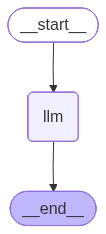

In [28]:
state_learning_graph = StateGraph(MessagesState)
state_learning_graph.add_node("llm", response_from_llm)

state_learning_graph.set_entry_point("llm")
state_learning_graph.set_finish_point("llm")

compiled_state_learning_graph = state_learning_graph.compile()
compiled_state_learning_graph

In [29]:
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="Hi this is Ram speaking")
output = compiled_state_learning_graph.invoke(
    {
        "messages": [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'service': 'aiplatform.googleapis.com'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [30]:
previous_message = output['messages']
previous_message

NameError: name 'output' is not defined

In [31]:
input_message = HumanMessage(content="What is my name ?")
output = compiled_state_learning_graph.invoke(
    {
        # There is a native way of doing this  => checkpoint, memory and thread
        "messages": previous_message + [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

NameError: name 'previous_message' is not defined

In [32]:
from langgraph.checkpoint.memory import InMemorySaver

memory_enabled_graph = state_learning_graph.compile(
    checkpointer=InMemorySaver()
)

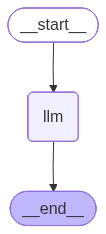

In [33]:
memory_enabled_graph

In [34]:
user1_config = {"configurable": {"thread_id": "1"}}
user2_config = {"configurable": {"thread_id": "2"}}

In [35]:
# user 1 conversations
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="Hi this is Ram")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [36]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="I live in Hyderabad")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [37]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="I live in Ameerpet")]
    },
    user1_config
)
print(f"length = {len(response['messages'])}")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [38]:
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

NameError: name 'response' is not defined

In [39]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="Where do i live in Mumbai ?")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [41]:
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="What is my name ?")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")
my_state = MessagesState(
    messages = response['messages']
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'consumer': 'projects/munna-genai', 'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'containerInfo': 'munna-genai', 'service': 'aiplatform.googleapis.com'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [42]:
# user 2
response = memory_enabled_graph.invoke(
    {
        "messages": [HumanMessage(content="What is my name")]
    },
    user2_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [43]:
def summarize(state: MessagesState):
    messages = state["messages"]
    response = llm.invoke([
        SystemMessage(content="Summarize the conversation"),
        *messages
    ])
    return response['messages']

In [44]:
messages = summarize(my_state)

NameError: name 'my_state' is not defined

In [45]:
len(messages)

NameError: name 'messages' is not defined

In [46]:
messages[-1].pretty_print()

NameError: name 'messages' is not defined

In [47]:

from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore

class StudentState(MessagesState):
    name: str
    email: str
    dept: str


def process_student_info(state: StudentState, runtime: Runtime):
    content= f"Student {state['name']} from {state['dept']} has email {state['email']}"
    if True:
        # retrieving from long term memory
        preference = runtime.store.get(
            namespace=("students",state['name'], "preference"),
            key="preference",
        )
        if preference:
            content += f" and prefers {preference}"


    return {
        "messages": llm.invoke(
            [
                SystemMessage(content="You are helpful student advisor, Act as an employee of Delhi University"),
                HumanMessage(
                    content=content),
                *state['messages']
            ]
        )
    }

def evaluate_result(state: StudentState, runtime: Runtime):
    if True:
        # storing in long term memory
        runtime.store.put(
            namespace=("students",state['name'], "preference"),
            key="preference",
            value=response['messages'][-1].content
        )
    return state

In [48]:
student_graph_builder = StateGraph(StudentState)

student_graph_builder.add_node("process", process_student_info)
student_graph_builder.add_node("evaluate", evaluate_result)

student_graph_builder.set_entry_point("process")
student_graph_builder.add_edge("process", "evaluate")
student_graph_builder.set_finish_point("evaluate")

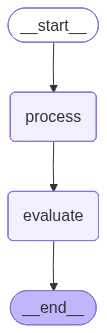

In [49]:
# compile the graph
student_graph = student_graph_builder.compile(
    checkpointer=InMemorySaver(),
    store=InMemoryStore()
)

student_graph

In [50]:
student1_config = {"configurable": {"thread_id": "1"}}
student2_config = {"configurable": {"thread_id": "2"}}


response = student_graph.invoke(
    {
        "name": "Ram",
        "email": "ram@gmail.com",
        "dept": "commerce",
        "messages": [
            HumanMessage(content="I want to know Sports Activities, As i like football")]
    },
    config=student1_config
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'service': 'aiplatform.googleapis.com', 'containerInfo': 'munna-genai', 'consumer': 'projects/munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o

In [51]:
def print_all_messages(messages: list[BaseMessage]):
    for message in messages:
        message.pretty_print()

In [52]:
print_all_messages(response['messages'])

NameError: name 'response' is not defined

In [53]:
response = student_graph.invoke(
    {
        "name": "Ram",
        "email": "ram@gmail.com",
        "dept": "commerce",
        "messages": [
            HumanMessage(
                content="What do i like ?"
            )
        ]
    },
    config=student1_config
)
print_all_messages(response['messages'])

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (PERMISSION_DENIED): 403 PERMISSION_DENIED. {'error': {'code': 403, 'message': 'This API method requires billing to be enabled. Please enable billing on project #munna-genai by visiting https://console.developers.google.com/billing/enable?project=munna-genai then retry. If you enabled billing for this project recently, wait a few minutes for the action to propagate to our systems and retry.', 'status': 'PERMISSION_DENIED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'BILLING_DISABLED', 'domain': 'googleapis.com', 'metadata': {'consoleUrl': 'https://console.developers.google.com/billing/enable?project=munna-genai', 'service': 'aiplatform.googleapis.com', 'consumer': 'projects/munna-genai', 'containerInfo': 'munna-genai'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'This API method requires billing to be enabled. Please enable billing o